# Gold Price Nowcasting from Cross-Asset Prices

## Problem
Can gold's daily value be explained by the same-day prices of other major
assets? This project builds a **nowcasting** model that estimates the SPDR
Gold ETF (GLD) from four cross-asset prices measured on the same day:

- **SLV** — silver ETF
- **SPX** — S&P 500 index
- **USO** — oil ETF
- **EUR/USD** — euro / US dollar exchange rate

## What this is (and isn't)
This is a **nowcast**, not a forecast. It uses day-*t* asset prices to explain
day-*t* gold — estimating a contemporaneous cross-asset relationship. It does
**not** predict future prices and is not a trading signal.

## Approach
Two parallel tracks are built and compared:
1. **Price level** — model GLD in dollars.
2. **Daily returns** — model GLD's daily return.

Comparing the two tests how robust the relationship is: price levels are prone
to non-stationarity (drifting over time), while returns are more stable. All
data is split **chronologically** — never randomly — to avoid look-ahead
leakage, since the rows are time-ordered.

## Dataset
Daily prices, ~2,290 trading days (2008 – May 2018).
Source: Gold Price Data (Kaggle).

In [254]:
#importing necessary libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error,
)

import warnings
warnings.filterwarnings("ignore")

In [255]:
#loading the dataset
df =pd.read_csv('gold_price_data.csv')
print('data loaded successfully')

data loaded successfully


In [256]:
#shape of the dataset
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,01/02/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,01/03/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,01/04/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,01/07/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,01/08/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [257]:
#shape of the dataset
df.shape

(2290, 6)

In [325]:
#checking the datatypes of the columns in the dataset
print('=' * 50)
print("Data types:\n", df.dtypes)
print('=' * 50)

Data types:
 Date           datetime64[ns]
SPX                   float64
GLD                   float64
USO                   float64
SLV                   float64
EUR/USD               float64
gld_level             float64
gld_returns           float64
SPX_R1                float64
USO_R1                float64
SLV_R1                float64
EUR/USD_R1            float64
SPX_R5                float64
USO_R5                float64
EUR/USD_R5            float64
SLV_R5                float64
year                    int32
month                   int32
day                    object
dtype: object


In [259]:
#descriptive statistics of the dataset
df.describe

<bound method NDFrame.describe of             Date          SPX         GLD        USO      SLV   EUR/USD
0     01/02/2008  1447.160034   84.860001  78.470001  15.1800  1.471692
1     01/03/2008  1447.160034   85.570000  78.370003  15.2850  1.474491
2     01/04/2008  1411.630005   85.129997  77.309998  15.1670  1.475492
3     01/07/2008  1416.180054   84.769997  75.500000  15.0530  1.468299
4     01/08/2008  1390.189941   86.779999  76.059998  15.5900  1.557099
...          ...          ...         ...        ...      ...       ...
2285  05/08/2018  2671.919922  124.589996  14.060000  15.5100  1.186789
2286  05/09/2018  2697.790039  124.330002  14.370000  15.5300  1.184722
2287  05/10/2018  2723.070068  125.180000  14.410000  15.7400  1.191753
2288   5/14/2018  2730.129883  124.489998  14.380000  15.5600  1.193118
2289   5/16/2018  2725.780029  122.543800  14.405800  15.4542  1.182033

[2290 rows x 6 columns]>

In [260]:
#missing values in the dataset
print('missing values:\n', df.isnull().sum())

missing values:
 Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64


In [261]:
#changing the date column to datetime format and sorting the data by date
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

In [262]:
#checking for gaps in the data
gaps = df['Date'].diff().dt.days
print(gaps.value_counts().sort_index)
print(df.loc[gaps > 4,['Date']].assign(gap=gaps[gaps > 4]))

<bound method Series.sort_index of Date
1.0     1727
4.0      316
3.0      191
5.0       29
2.0       23
8.0        1
18.0       1
6.0        1
Name: count, dtype: int64>
           Date   gap
90   2008-05-27   5.0
109  2008-07-01   5.0
127  2008-08-07   8.0
128  2008-08-25  18.0
132  2008-09-02   5.0
300  2009-05-26   5.0
359  2009-09-08   5.0
527  2010-06-01   5.0
546  2010-07-06   5.0
581  2010-09-07   5.0
749  2011-05-31   5.0
768  2011-07-05   5.0
803  2011-09-06   5.0
970  2012-05-29   5.0
1024 2012-09-04   5.0
1055 2012-10-31   6.0
1188 2013-05-28   5.0
1210 2013-07-08   5.0
1242 2013-09-03   5.0
1261 2013-10-08   5.0
1409 2014-05-27   5.0
1464 2014-09-02   5.0
1632 2015-05-26   5.0
1691 2015-09-08   5.0
1698 2015-09-22   5.0
1857 2016-05-31   5.0
1876 2016-07-05   5.0
1911 2016-09-06   5.0
2078 2017-05-30   5.0
2100 2017-07-11   5.0
2131 2017-09-05   5.0
2175 2017-11-20   5.0


In [324]:
# View a subset of the DataFrame
df[120:130]

,Date,SPX,GLD,USO,SLV,EUR/USD,gld_level,gld_returns,SPX_R1,USO_R1,SLV_R1,EUR/USD_R1,SPX_R5,USO_R5,EUR/USD_R5,SLV_R5,year,month,day
120,2008-07-21,1260.000000,95.120003,106.669998,18.228001,1.579205,95.120003,0.009552,1260.000000,106.669998,18.228001,1.579205,1241.778003,110.264000,1.584458,18.545600,2008,7,Monday
121,2008-07-22,1277.000000,93.059998,103.320000,17.759001,1.569243,93.059998,-0.021657,1277.000000,103.320000,17.759001,1.569243,1251.517993,107.431999,1.580326,18.310401,2008,7,Tuesday
122,2008-07-23,1282.189941,90.570000,100.019997,17.190001,1.568874,90.570000,-0.026757,1282.189941,100.019997,17.190001,1.568874,1264.973974,104.957999,1.577660,18.008401,2008,7,Wednesday
123,2008-07-24,1252.540039,91.330002,101.459999,17.260000,1.567300,91.330002,0.008391,1252.540039,101.459999,17.260000,1.567300,1266.409985,103.399999,1.574002,17.751401,2008,7,Thursday
124,2008-07-28,1234.369995,91.730003,100.540001,17.360001,1.559090,91.730003,0.004380,1234.369995,100.540001,17.360001,1.559090,1261.219995,102.401999,1.568742,17.559401,2008,7,Monday
125,2008-07-29,1263.199951,90.589996,98.040001,17.190001,1.557366,90.589996,-0.012428,1263.199951,98.040001,17.190001,1.557366,1261.859985,100.676000,1.564375,17.351801,2008,7,Tuesday
126,2008-07-30,1284.260010,89.519997,102.129997,17.360001,1.559308,89.519997,-0.011811,1284.260010,102.129997,17.360001,1.559308,1263.311987,100.437999,1.562388,17.272001,2008,7,Wednesday
127,2008-08-07,1266.069946,86.089996,96.440002,16.070000,1.504891,86.089996,-0.038315,1266.069946,96.440002,16.070000,1.504891,1260.087988,99.722000,1.549591,17.048001,2008,8,Thursday
128,2008-08-25,1266.839966,80.930000,93.099998,13.330000,1.464794,80.930000,-0.059937,1266.839966,93.099998,13.330000,1.464794,1262.947974,98.050000,1.529090,16.262001,2008,8,Monday
129,2008-08-26,1271.510010,81.230003,93.900002,13.450000,1.472581,81.230003,0.003707,1271.510010,93.900002,13.450000,1.472581,1270.375977,96.722000,1.511788,15.480000,2008,8,Tuesday


In [264]:
gap_report  = df.loc[gaps > 4,['Date']].assign(gap=gaps[gaps > 4])


In [265]:
gap_report["gap_days"] =gaps[gaps>4]
gap_report['prev_day'] = df['Date'].shift(1)[gaps>4]
gap_report['weekday'] = gap_report['Date'].dt.day_name()
gap_report['prev_weekday'] = gap_report['prev_day'].dt.day_name()

print(gap_report.head(5))

          Date   gap  gap_days   prev_day   weekday prev_weekday
90  2008-05-27   5.0       5.0 2008-05-22   Tuesday     Thursday
109 2008-07-01   5.0       5.0 2008-06-26   Tuesday     Thursday
127 2008-08-07   8.0       8.0 2008-07-30  Thursday    Wednesday
128 2008-08-25  18.0      18.0 2008-08-07    Monday     Thursday
132 2008-09-02   5.0       5.0 2008-08-28   Tuesday     Thursday


In [266]:
print('the shape of the gap_report is:', gap_report.shape[0])

the shape of the gap_report is: 32


In [267]:
# The entire table of the gap_report
gap_report_copy = gap_report.copy()
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    display(gap_report_copy)


,Date,gap,gap_days,prev_day,weekday,prev_weekday
90,2008-05-27,5.0,5.0,2008-05-22,Tuesday,Thursday
109,2008-07-01,5.0,5.0,2008-06-26,Tuesday,Thursday
127,2008-08-07,8.0,8.0,2008-07-30,Thursday,Wednesday
128,2008-08-25,18.0,18.0,2008-08-07,Monday,Thursday
132,2008-09-02,5.0,5.0,2008-08-28,Tuesday,Thursday
300,2009-05-26,5.0,5.0,2009-05-21,Tuesday,Thursday
359,2009-09-08,5.0,5.0,2009-09-03,Tuesday,Thursday
527,2010-06-01,5.0,5.0,2010-05-27,Tuesday,Thursday
546,2010-07-06,5.0,5.0,2010-07-01,Tuesday,Thursday
581,2010-09-07,5.0,5.0,2010-09-02,Tuesday,Thursday


In [268]:
df.columns

Index(['Date', 'SPX', 'GLD', 'USO', 'SLV', 'EUR/USD'], dtype='object')

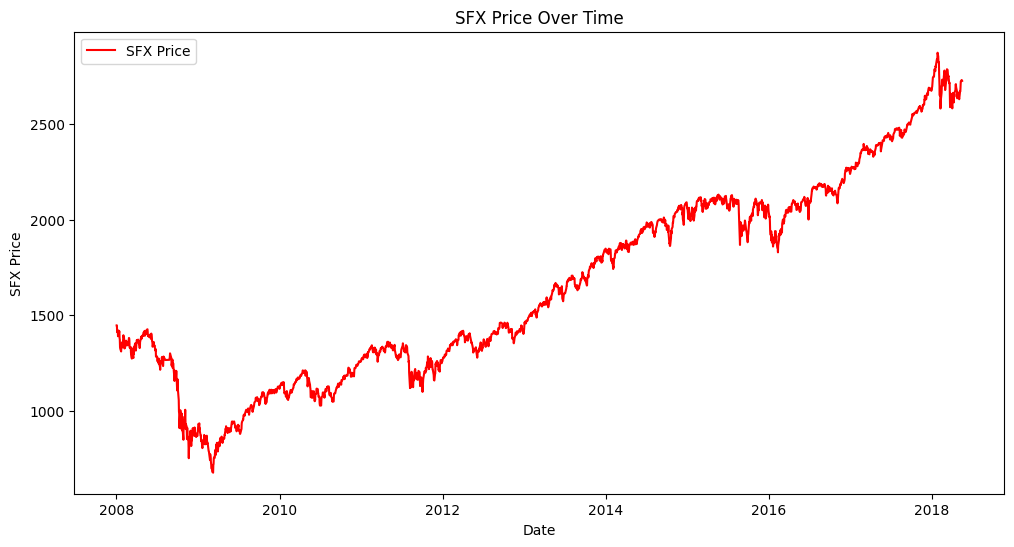

In [269]:
#plotting SFX over time
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['SPX'], color='red', label='SFX Price')
plt.title('SFX Price Over Time')
plt.xlabel('Date')
plt.ylabel('SFX Price')
plt.legend()
plt.show()

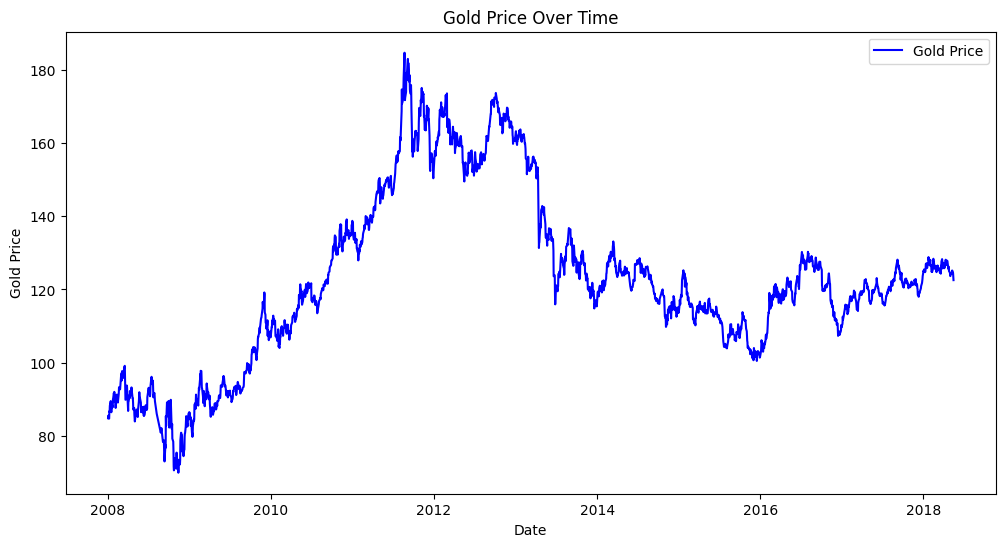

In [270]:
#plotting Gold over time
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['GLD'], color='blue', label='Gold Price')
plt.title('Gold Price Over Time')
plt.xlabel('Date')
plt.ylabel('Gold Price')
plt.legend()
plt.show()

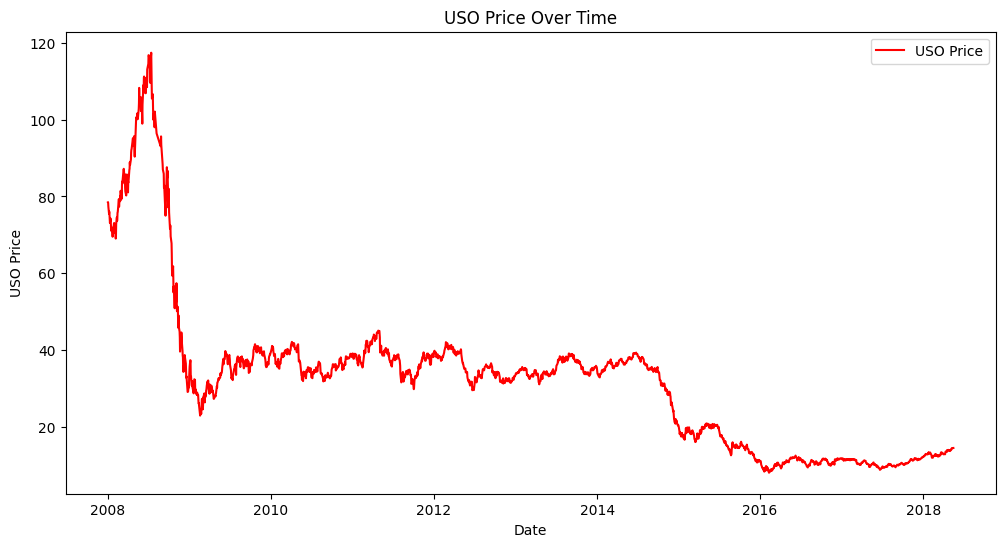

In [271]:
#plotting USO over time
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['USO'], color='red', label='USO Price')
plt.title('USO Price Over Time')
plt.xlabel('Date')
plt.ylabel('USO Price')
plt.legend()
plt.show()

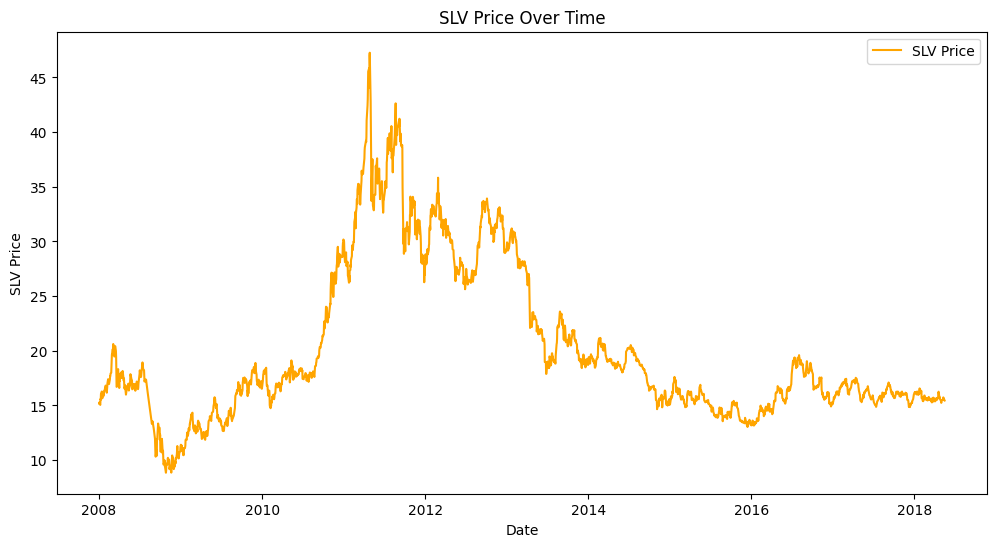

In [272]:
#plotting SLV over time
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['SLV'], color='orange', label='SLV Price')
plt.title('SLV Price Over Time')
plt.xlabel('Date')
plt.ylabel('SLV Price')
plt.legend()
plt.show()

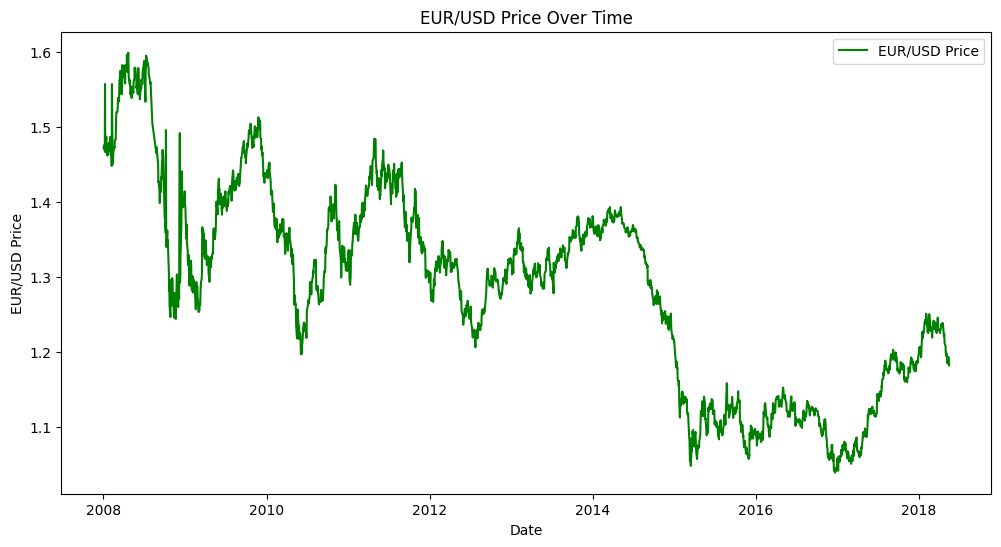

In [273]:
#plotting EUR/USD over time
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['EUR/USD'], color='green', label='EUR/USD Price')
plt.title('EUR/USD Price Over Time')
plt.xlabel('Date')
plt.ylabel('EUR/USD Price')
plt.legend()
plt.show()

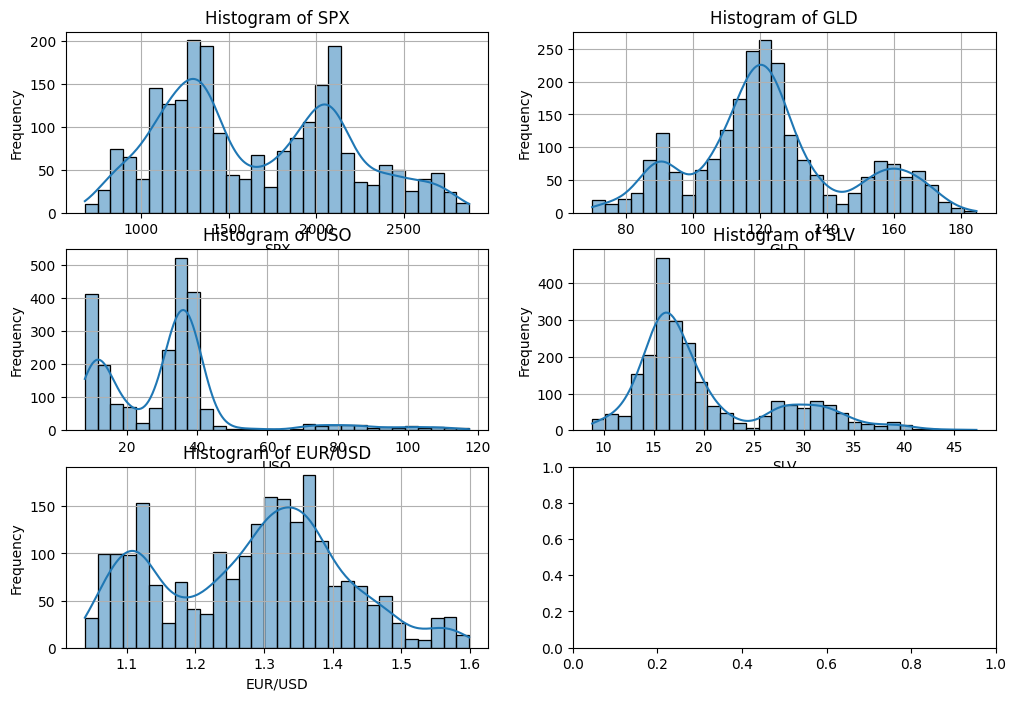

In [274]:
#plotting histogram of all features
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 8))

for i, column in enumerate(df.columns[1:]):
    ax = axes[i // 2, i % 2]
    sns.histplot(df[column], bins=30, kde=True, ax=ax)
    ax.set_title(f'Histogram of {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequency')
    ax.grid(True)

<Axes: >

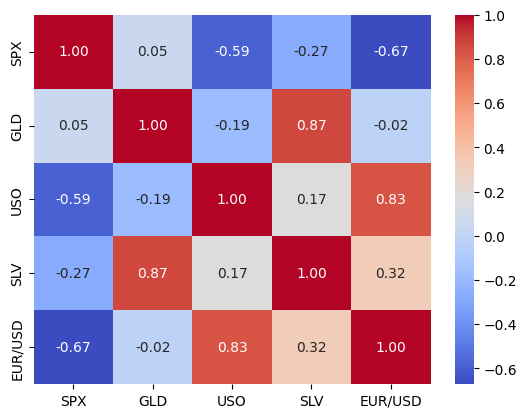

In [275]:
#correlation matrix and heatmap
correlation_matrix = df[['SPX', 'GLD', 'USO', 'SLV', 'EUR/USD']].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

In [276]:
#running return correlaion aalysis for validity

returns = df[['SPX', 'GLD', 'USO', 'SLV', 'EUR/USD']].pct_change()

bad = gaps > 4

returns[bad] = np.nan

<Axes: >

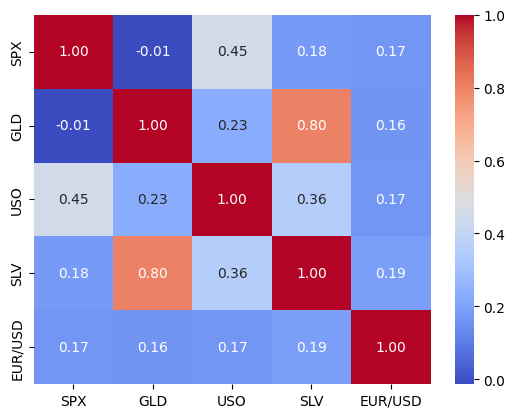

In [277]:
correlation_matrix_returns = returns.corr()
sns.heatmap(correlation_matrix_returns, annot=True, cmap='coolwarm', fmt=".2f")

## Feature Engineering 

In [ ]:

df['gld_level'] =  df[['GLD']]

df['gld_returns'] = df['GLD'].pct_change()

In [279]:
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD,gld_level,gld_returns
0,2008-01-02,1447.160034,84.860001,78.470001,15.180,1.471692,84.860001,NaN
1,2008-01-03,1447.160034,85.570000,78.370003,15.285,1.474491,85.570000,0.008367
2,2008-01-04,1411.630005,85.129997,77.309998,15.167,1.475492,85.129997,-0.005142
3,2008-01-07,1416.180054,84.769997,75.500000,15.053,1.468299,84.769997,-0.004229
4,2008-01-08,1390.189941,86.779999,76.059998,15.590,1.557099,86.779999,0.023711


In [280]:
#rolling means for all features 
#rolling for a day
df["SPX_R1"] = df['SPX'].rolling(window=1).mean()
df["USO_R1"] = df['USO'].rolling(window=1).mean()
df['SLV_R1'] = df['SLV'].rolling(window=1).mean()
df['EUR/USD_R1'] = df['EUR/USD'].rolling(window=1).mean()



#rolling for 5 days
df["SPX_R5"] = df['SPX'].rolling(window=5).mean()
df["USO_R5"] = df['USO'].rolling(window=5).mean()
df['EUR/USD_R5'] = df['EUR/USD'].rolling(window=5).mean()
df['SLV_R5'] = df['SLV'].rolling(window=5).mean()

In [281]:
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD,gld_level,gld_returns,SPX_R1,USO_R1,SLV_R1,EUR/USD_R1,SPX_R5,USO_R5,EUR/USD_R5,SLV_R5
0,2008-01-02,1447.160034,84.860001,78.470001,15.180,1.471692,84.860001,NaN,1447.160034,78.470001,15.180,1.471692,NaN,NaN,NaN,NaN
1,2008-01-03,1447.160034,85.570000,78.370003,15.285,1.474491,85.570000,0.008367,1447.160034,78.370003,15.285,1.474491,NaN,NaN,NaN,NaN
2,2008-01-04,1411.630005,85.129997,77.309998,15.167,1.475492,85.129997,-0.005142,1411.630005,77.309998,15.167,1.475492,NaN,NaN,NaN,NaN
3,2008-01-07,1416.180054,84.769997,75.500000,15.053,1.468299,84.769997,-0.004229,1416.180054,75.500000,15.053,1.468299,NaN,NaN,NaN,NaN
4,2008-01-08,1390.189941,86.779999,76.059998,15.590,1.557099,86.779999,0.023711,1390.189941,76.059998,15.590,1.557099,1422.464014,77.142,1.489415,15.255


In [282]:
#seting the date column into year, month and day columns
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day_name()

In [283]:
dff = df.copy()

In [284]:
dff.drop(['gld_returns'], axis=1, inplace=True)

In [285]:
dff.head()

,Date,SPX,GLD,USO,SLV,EUR/USD,gld_level,SPX_R1,USO_R1,SLV_R1,EUR/USD_R1,SPX_R5,USO_R5,EUR/USD_R5,SLV_R5,year,month,day
0,2008-01-02,1447.160034,84.860001,78.470001,15.180,1.471692,84.860001,1447.160034,78.470001,15.180,1.471692,NaN,NaN,NaN,NaN,2008,1,Wednesday
1,2008-01-03,1447.160034,85.570000,78.370003,15.285,1.474491,85.570000,1447.160034,78.370003,15.285,1.474491,NaN,NaN,NaN,NaN,2008,1,Thursday
2,2008-01-04,1411.630005,85.129997,77.309998,15.167,1.475492,85.129997,1411.630005,77.309998,15.167,1.475492,NaN,NaN,NaN,NaN,2008,1,Friday
3,2008-01-07,1416.180054,84.769997,75.500000,15.053,1.468299,84.769997,1416.180054,75.500000,15.053,1.468299,NaN,NaN,NaN,NaN,2008,1,Monday
4,2008-01-08,1390.189941,86.779999,76.059998,15.590,1.557099,86.779999,1390.189941,76.059998,15.590,1.557099,1422.464014,77.142,1.489415,15.255,2008,1,Tuesday


In [286]:
returns_dff = dff[['SPX', 'USO', 'SLV', 'EUR/USD']].pct_change()

returns_dff['gld_returns'] = df['GLD'].pct_change()

In [287]:
returns_dff['Date'] = df['Date']

returns_gaps = returns_dff['Date'].diff().dt.days

In [288]:
# Identifying bad returns
return_bad = returns_gaps > 4

returns_dff[return_bad] = np.nan

In [289]:
returns_dff.head()

,SPX,USO,SLV,EUR/USD,gld_returns,Date
0,NaN,NaN,NaN,NaN,NaN,2008-01-02
1,0.000000,-0.001274,0.006917,0.001902,0.008367,2008-01-03
2,-0.024552,-0.013526,-0.007720,0.000679,-0.005142,2008-01-04
3,0.003223,-0.023412,-0.007516,-0.004875,-0.004229,2008-01-07
4,-0.018352,0.007417,0.035674,0.060478,0.023711,2008-01-08


In [290]:
print('the number of NaN values in the dff dataframe is:', dff.isnull().sum().sum())

print('the number of NaN values in the returns dataframe is:', returns_dff.isnull().sum().sum())

the number of NaN values in the dff dataframe is: 16
the number of NaN values in the returns dataframe is: 197


In [291]:
#rolling of every feature in the returns_dff dataframe for  a day and 5 days

#rolling for a day
returns_dff['SPX_R1'] = returns_dff['SPX'].rolling(window=1).mean()
returns_dff['USO_R1'] = returns_dff['USO'].rolling(window=1).mean()
returns_dff['SLV_R1'] = returns_dff['SLV'].rolling(window=1).mean()
returns_dff['EUR/USD_R1'] = returns_dff['EUR/USD'].rolling(window=1).mean()

#rolling for 5 days
returns_dff['SPX_R5'] = returns_dff['SPX'].rolling(window=5).mean()
returns_dff['USO_R5'] = returns_dff['USO'].rolling(window=5).mean()
returns_dff['SLV_R5'] = returns_dff['SLV'].rolling(window=5).mean()
returns_dff['EUR/USD_R5'] = returns_dff['EUR/USD'].rolling(window=5).mean()


In [292]:
returns_dff['year'] = returns_dff['Date'].dt.year
returns_dff['month'] = returns_dff['Date'].dt.month
returns_dff['day'] = returns_dff['Date'].dt.day_name()

In [293]:
returns_dff.head(10)

,SPX,USO,SLV,EUR/USD,gld_returns,Date,SPX_R1,USO_R1,SLV_R1,EUR/USD_R1,SPX_R5,USO_R5,SLV_R5,EUR/USD_R5,year,month,day
0,NaN,NaN,NaN,NaN,NaN,2008-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008.0,1.0,Wednesday
1,0.000000,-0.001274,0.006917,0.001902,0.008367,2008-01-03,0.000000,-0.001274,0.006917,0.001902,NaN,NaN,NaN,NaN,2008.0,1.0,Thursday
2,-0.024552,-0.013526,-0.007720,0.000679,-0.005142,2008-01-04,-0.024552,-0.013526,-0.007720,0.000679,NaN,NaN,NaN,NaN,2008.0,1.0,Friday
3,0.003223,-0.023412,-0.007516,-0.004875,-0.004229,2008-01-07,0.003223,-0.023412,-0.007516,-0.004875,NaN,NaN,NaN,NaN,2008.0,1.0,Monday
4,-0.018352,0.007417,0.035674,0.060478,0.023711,2008-01-08,-0.018352,0.007417,0.035674,0.060478,NaN,NaN,NaN,NaN,2008.0,1.0,Tuesday
5,0.013624,-0.010649,-0.004490,-0.058245,-0.002650,2008-01-09,0.013624,-0.010649,-0.004490,-0.058245,-0.005211,-0.008289,0.004573,-0.000012,2008.0,1.0,Wednesday
6,0.007948,-0.016346,0.034858,0.009339,0.019642,2008-01-10,0.007948,-0.016346,0.034858,0.009339,-0.003622,-0.011303,0.010161,0.001475,2008.0,1.0,Thursday
7,-0.013595,-0.012564,0.000996,-0.000739,0.003739,2008-01-11,-0.013595,-0.012564,0.000996,-0.000739,-0.001430,-0.011111,0.011904,0.001192,2008.0,1.0,Friday
8,0.010871,0.015871,0.012627,0.005337,0.010838,2008-01-14,0.010871,0.015871,0.012627,0.005337,0.000099,-0.003254,0.015933,0.003234,2008.0,1.0,Monday
9,-0.024925,-0.019798,-0.027396,-0.004499,-0.017311,2008-01-15,-0.024925,-0.019798,-0.027396,-0.004499,-0.001216,-0.008697,0.003319,-0.009761,2008.0,1.0,Tuesday


In [294]:
print('the number of NaN values in the returns_dff dataframe is:', returns_dff.isnull().sum().sum())

print('the number of NaN values in the dff dataframe is:', dff.isnull().sum().sum())

the number of NaN values in the returns_dff dataframe is: 1065
the number of NaN values in the dff dataframe is: 16


In [295]:
#dropping NaN values from both dataframes
dff = dff.dropna()

returns_dff = returns_dff.dropna()

In [296]:
print('the number of NaN values in the returns_dff dataframe is:', returns_dff.isnull().sum().sum())

print('the number of NaN values in the dff dataframe is:', dff.isnull().sum().sum())

the number of NaN values in the returns_dff dataframe is: 0
the number of NaN values in the dff dataframe is: 0


In [297]:
returns_dff.head()

,SPX,USO,SLV,EUR/USD,gld_returns,Date,SPX_R1,USO_R1,SLV_R1,EUR/USD_R1,SPX_R5,USO_R5,SLV_R5,EUR/USD_R5,year,month,day
5,0.013624,-0.010649,-0.004490,-0.058245,-0.002650,2008-01-09,0.013624,-0.010649,-0.004490,-0.058245,-0.005211,-0.008289,0.004573,-0.000012,2008.0,1.0,Wednesday
6,0.007948,-0.016346,0.034858,0.009339,0.019642,2008-01-10,0.007948,-0.016346,0.034858,0.009339,-0.003622,-0.011303,0.010161,0.001475,2008.0,1.0,Thursday
7,-0.013595,-0.012564,0.000996,-0.000739,0.003739,2008-01-11,-0.013595,-0.012564,0.000996,-0.000739,-0.001430,-0.011111,0.011904,0.001192,2008.0,1.0,Friday
8,0.010871,0.015871,0.012627,0.005337,0.010838,2008-01-14,0.010871,0.015871,0.012627,0.005337,0.000099,-0.003254,0.015933,0.003234,2008.0,1.0,Monday
9,-0.024925,-0.019798,-0.027396,-0.004499,-0.017311,2008-01-15,-0.024925,-0.019798,-0.027396,-0.004499,-0.001216,-0.008697,0.003319,-0.009761,2008.0,1.0,Tuesday


In [298]:
print(dff.columns.tolist())
print(returns_dff.columns.tolist())
print(dff.shape, returns.shape)     

['Date', 'SPX', 'GLD', 'USO', 'SLV', 'EUR/USD', 'gld_level', 'SPX_R1', 'USO_R1', 'SLV_R1', 'EUR/USD_R1', 'SPX_R5', 'USO_R5', 'EUR/USD_R5', 'SLV_R5', 'year', 'month', 'day']
['SPX', 'USO', 'SLV', 'EUR/USD', 'gld_returns', 'Date', 'SPX_R1', 'USO_R1', 'SLV_R1', 'EUR/USD_R1', 'SPX_R5', 'USO_R5', 'SLV_R5', 'EUR/USD_R5', 'year', 'month', 'day']
(2286, 18) (2290, 5)


In [299]:
#checking the chronological order of the dataframes
print(dff['Date'].is_monotonic_increasing)
print(returns_dff['Date'].is_monotonic_increasing)

True
True


In [300]:
#spliting the data into training and testing sets

cutoff_date = '2017-01-01'

train_dff = dff[dff['Date'] < cutoff_date]
test_dff = dff[dff['Date'] >= cutoff_date]

print('the shape of the training set is:', train_dff.shape)
print('the shape of the testing set is:', test_dff.shape)   

the shape of the training set is: (1981, 18)
the shape of the testing set is: (305, 18)


In [301]:
#for level data
x_level = dff.drop(['Date', 'GLD', 'gld_level'], axis=1)
y_level = dff['GLD']

#for returns data
x_returns = returns_dff.drop(['Date', 'gld_returns'], axis=1)
y_returns = returns_dff['gld_returns']

In [302]:
#splitting the data into train and test sets

cutoff_date = '2017-01-01'

#FOR LEVEL DATA
train_level_mask = dff['Date'] < cutoff_date
test_level_mask = dff['Date'] >= cutoff_date

#data split for level
x_train_level, y_train_level = x_level[train_level_mask], y_level[train_level_mask]
x_test_level, y_test_level = x_level[test_level_mask], y_level[test_level_mask]

#FOR RETURNS DATA
train_returns_mask = returns_dff['Date'] < cutoff_date
test_returns_mask = returns_dff['Date'] >= cutoff_date

#data split for returns
x_train_returns, y_train_returns = x_returns[train_returns_mask], y_returns[train_returns_mask]
x_test_returns, y_test_returns = x_returns[test_returns_mask], y_returns[test_returns_mask]



In [303]:
#confirming the shapes of the training and testing sets for both level and returns data
print("Shapes of Training and Testing Sets:")
print("X_train Level (SLV):", x_train_level.shape)
print("X_test Level (SLV):", x_test_level.shape)
print("y_train Level:", y_train_level.shape)
print("y_test Level:", y_test_level.shape)

Shapes of Training and Testing Sets:
X_train Level (SLV): (1981, 15)
X_test Level (SLV): (305, 15)
y_train Level: (1981,)
y_test Level: (305,)


In [304]:
#test set date range for level data
print("Test Set Date Range:", dff[test_level_mask]["Date"].min(), dff[test_level_mask]["Date"].max())

Test Set Date Range: 2017-01-03 00:00:00 2018-05-16 00:00:00


In [305]:
x_train_level.columns.to_list()

['SPX',
 'USO',
 'SLV',
 'EUR/USD',
 'SPX_R1',
 'USO_R1',
 'SLV_R1',
 'EUR/USD_R1',
 'SPX_R5',
 'USO_R5',
 'EUR/USD_R5',
 'SLV_R5',
 'year',
 'month',
 'day']

In [306]:
x_train_level.columns.to_list()

['SPX',
 'USO',
 'SLV',
 'EUR/USD',
 'SPX_R1',
 'USO_R1',
 'SLV_R1',
 'EUR/USD_R1',
 'SPX_R5',
 'USO_R5',
 'EUR/USD_R5',
 'SLV_R5',
 'year',
 'month',
 'day']

In [307]:
#setting two baselines 

#baseline 1: using the mean of the training set as the prediction for the test set
baseline_1_pred = np.full(len(y_test_level), y_train_level.mean())

#baseline 2: comparison with slv only
baseline_2_model   =  LinearRegression()
baseline_2_model.fit(x_train_level[['SLV']], y_train_level)
baseline_2_pred = baseline_2_model.predict(x_test_level[['SLV']])



In [308]:
#scores of the two baselines 

for name,pred in zip(['Baseline 1', 'Baseline 2'], [baseline_1_pred, baseline_2_pred]):
    print("=" * 70)
    print(f"Scores for {name}:")
    print(f"Mean Squared Error: {mean_squared_error(y_test_level, pred)}")
    print(f"Mean Absolute Error: {mean_absolute_error(y_test_level, pred)}")
    print(f"R^2 Score: {r2_score(y_test_level, pred)}")
    print(f"Mean Absolute Percentage Error: {mean_absolute_percentage_error(y_test_level, pred)}")
    print("=" * 70)

Scores for Baseline 1:
Mean Squared Error: 18.674688004896574
Mean Absolute Error: 3.5944123027316914
R^2 Score: -0.1643208459596548
Mean Absolute Percentage Error: 0.030070294365905508
Scores for Baseline 2:
Mean Squared Error: 172.26727602136344
Mean Absolute Error: 12.331001032461076
R^2 Score: -9.740440777150756
Mean Absolute Percentage Error: 0.10055609693634557


In [309]:
# Print the min and max values for each dataset
print("X_train Level (SLV):", x_train_level["SLV"].min(), x_train_level["SLV"].max())
print("X_test Level (SLV):", x_test_level["SLV"].min(), x_test_level["SLV"].max())
print("y_train Level:", y_train_level.min(), y_train_level.max())
print("y_test Level:", y_test_level.min(), y_test_level.max())

X_train Level (SLV): 8.85 47.259998
X_test Level (SLV): 14.85 17.530001
y_train Level: 70.0 184.589996
y_test Level: 110.470001 128.830002


In [310]:
#setting wo baselines for the returns data

#baseline 1: using the mean of the training set as the prediction for the test set
baseline_1_pred_returns = np.full(len(y_test_returns), y_train_returns.mean())

#baseline 2: comparison with slv only
baseline_2_model_returns   =  LinearRegression()
baseline_2_model_returns.fit(x_train_returns[['SLV']], y_train_returns)
baseline_2_pred_returns = baseline_2_model_returns.predict(x_test_returns[['SLV']])

In [311]:
#scores of the two baselines for returns data

for name,pred in zip(['Baseline 1', 'Baseline 2'], [baseline_1_pred_returns, baseline_2_pred_returns]):
    print("=" * 70)
    print(f"Scores for {name}:")
    print(f"Mean Squared Error: {mean_squared_error(y_test_returns, pred)}")
    print(f"Mean Absolute Error: {mean_absolute_error(y_test_returns, pred)}")
    print(f"R^2 Score: {r2_score(y_test_returns, pred)}")
    print(f"Mean Absolute Percentage Error: {mean_absolute_percentage_error(y_test_returns, pred)}")
    print("=" * 70) 

Scores for Baseline 1:
Mean Squared Error: 4.481811842561194e-05
Mean Absolute Error: 0.005263061660462242
R^2 Score: -6.500037997336783e-05
Mean Absolute Percentage Error: 7982520373.0573845
Scores for Baseline 2:
Mean Squared Error: 1.4050135727704006e-05
Mean Absolute Error: 0.0028971545897530887
R^2 Score: 0.686487307244132
Mean Absolute Percentage Error: 11937853484.655636


In [312]:
#setting the new model for the returns data

#dropping the day column since regression does not work with strings
X_train_real_returns = x_train_returns.drop(columns = ["day"])
X_test_real_returns = x_test_returns.drop(columns = ["day"])


In [313]:
#using linear regression for the returns data
lr = LinearRegression()
lr.fit(X_train_real_returns, y_train_returns)
lr_pred = lr.predict(X_test_real_returns)

lr_mse = mean_squared_error(y_test_returns, lr_pred)
lr_mae = mean_absolute_error(y_test_returns, lr_pred)
lr_r2 = r2_score(y_test_returns, lr_pred)


In [314]:
#metrics for the linear regression model
print("=" * 70)
print("Scores for Linear Regression Model:")
print(f"Mean Squared Error: {lr_mse}")
print(f"Mean Absolute Error: {lr_mae}")
print(f"R-squared: {lr_r2}")
print( '=' * 70)

Scores for Linear Regression Model:
Mean Squared Error: 1.36299677850063e-05
Mean Absolute Error: 0.0028721555770890154
R-squared: 0.6958628738349308


In [315]:
#lasso and ridge regression for the returns data

for name, model in zip([('Ridge'), ('Lasso')],[Ridge(), Lasso()]):
    model.fit(X_train_real_returns, y_train_returns)
    pred = model.predict(X_test_real_returns)
    
    mse = mean_squared_error(y_test_returns, pred)
    mae = mean_absolute_error(y_test_returns, pred)
    r2 = r2_score(y_test_returns, pred)
    
    print("=" * 70)
    print(f"Scores for {name} Model:")
    print(f"Mean Squared Error: {mse}")
    print(f"Mean Absolute Error: {mae}")
    print(f"R-squared: {r2}")
    print("=" * 70)

Scores for Ridge Model:
Mean Squared Error: 1.7395250510997754e-05
Mean Absolute Error: 0.0032099838502832236
R-squared: 0.6118449006786215
Scores for Lasso Model:
Mean Squared Error: 4.481811842561194e-05
Mean Absolute Error: 0.005263061660462242
R-squared: -6.500037997336783e-05


In [316]:

#lasso regression with different alpha values to see the effect on R2 and number of features kept
for a in [0.0001, 0.00001, 0.000001]:
    lasso = Lasso(alpha=a).fit(X_train_real_returns, y_train_returns)
    pred = lasso.predict(X_test_real_returns)
    r2 = r2_score(y_test_returns, pred)
    n_kept = (lasso.coef_ != 0).sum()
    print('=' * 70)
    print(f"alpha={a}  R2={r2:.4f}  features kept={n_kept}")
    print('=' * 70)

alpha=0.0001  R2=0.5652  features kept=4
alpha=1e-05  R2=0.6947  features kept=6
alpha=1e-06  R2=0.6969  features kept=11


In [317]:

#checking the coefficients of the best lasso model to see which features are kept
best = Lasso(alpha=1e-05).fit(X_train_real_returns, y_train_returns)
lasso_coefs = pd.Series(best.coef_, index=X_train_real_returns.columns)
print(lasso_coefs[lasso_coefs != 0].sort_values(key=abs, ascending=False).round(5))

SLV       0.46297
SPX_R1   -0.05969
SPX      -0.03769
SLV_R1    0.00681
year     -0.00004
month     0.00000
dtype: float64


In [318]:
#random forest regressor

rf = RandomForestRegressor()
rf.fit(X_train_real_returns, y_train_returns)
rf_pred = rf.predict(X_test_real_returns)

mse = mean_squared_error(y_test_returns, rf_pred)
mae = mean_absolute_error(y_test_returns, rf_pred)
r2 = r2_score(y_test_returns, rf_pred)

print("=" * 70)
print("Scores for Random Forest Regressor Model:")
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")
print("=" * 70)

Scores for Random Forest Regressor Model:
Mean Squared Error: 1.4347656766094712e-05
Mean Absolute Error: 0.0029716420806155555
R-squared: 0.679848465904438


In [319]:
#gradient boosting regressor

gbr = GradientBoostingRegressor()
gbr.fit(X_train_real_returns, y_train_returns)
gbr_pred = gbr.predict(X_test_real_returns)

mse = mean_squared_error(y_test_returns, gbr_pred)
mae = mean_absolute_error(y_test_returns, gbr_pred)
r2 = r2_score(y_test_returns, gbr_pred)

print("=" * 70)
print("Scores for Gradient Boosting Regressor Model:")
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")
print("=" * 70)


Scores for Gradient Boosting Regressor Model:
Mean Squared Error: 1.307299662147439e-05
Mean Absolute Error: 0.0028348577074631233
R-squared: 0.7082910476725648


In [320]:
#timesplits function for cross validation and hyperparameter tuning for the gradient boosting regressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators' : [100,200,300],
    'max_depth' : [2,3,4],
    'learning_rate' : [0.01,0.05,0.01]
}


grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42), 
    param_grid,
      cv=tscv, 
    scoring='r2', 
    n_jobs=-1
)

grid.fit(X_train_real_returns,y_train_returns)

best_estimator = grid.best_estimator_
pred_best = best_estimator.predict(X_test_real_returns)
test_best_r2 = r2_score(y_test_returns, pred_best)


print("=" * 70)
print("Best Gradient Boosting Regressor Model:")
print(f"Best Parameters: {grid.best_params_}")
print(f"Test R-squared: {test_best_r2}")
print("=" * 70)


Best Gradient Boosting Regressor Model:
Best Parameters: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}
Test R-squared: 0.6954715395429771


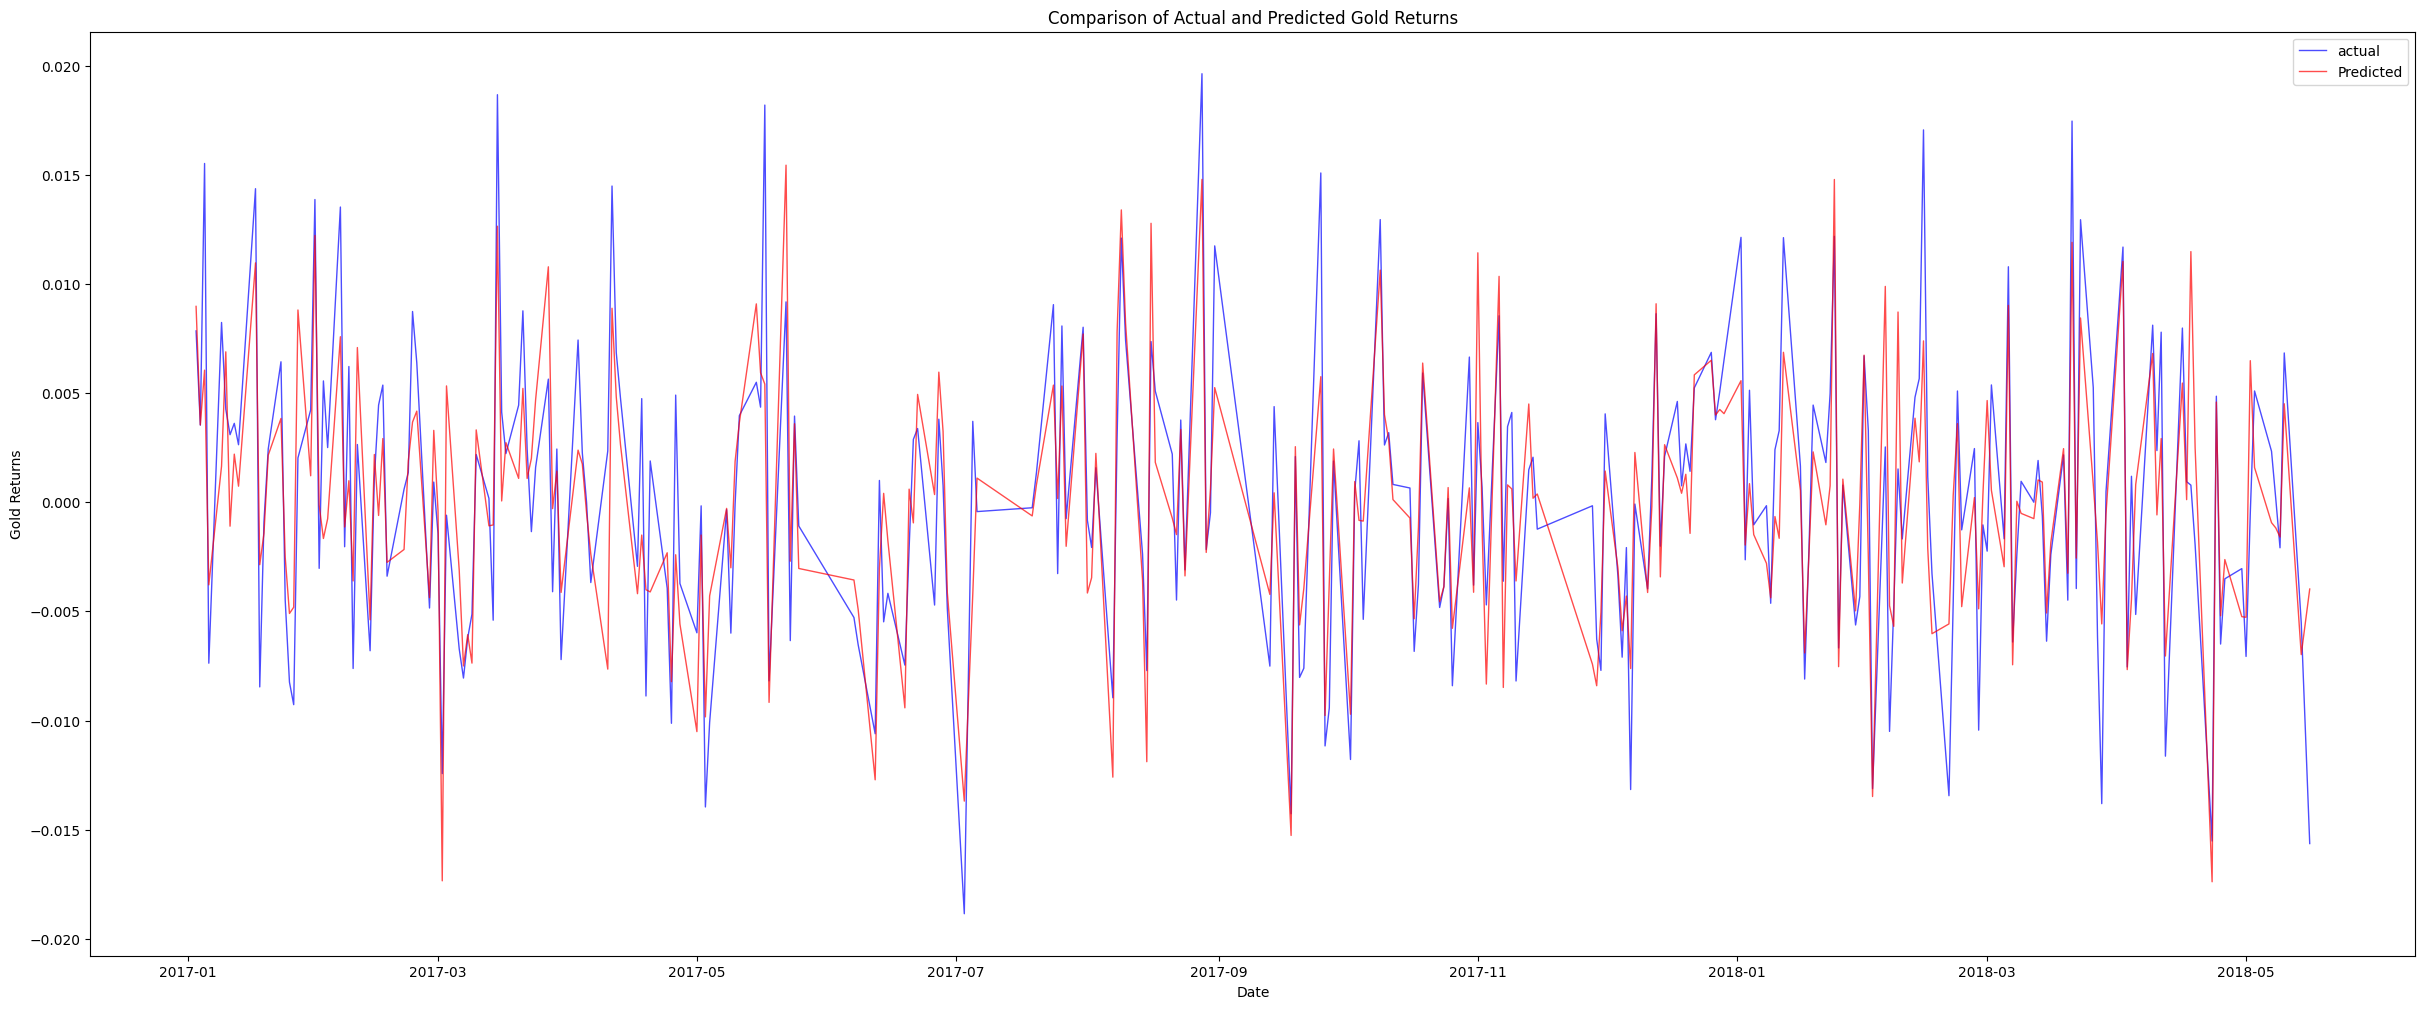

In [321]:
#making comparison with the actual and prediction of linearRegression
#remember test_returns_mask = returns_dff['Date'] >= cutoff_date and cutoff_date = '2017-01-01'

plt.figure(figsize=(30, 12))
plt.plot(returns_dff['Date'].loc[test_returns_mask], y_test_returns, label='actual', color='blue',alpha=0.7, linewidth=1)
plt.plot(returns_dff['Date'].loc[test_returns_mask], lr_pred, label='Predicted', color='red', alpha=0.7, linewidth=1)
plt.title('Comparison of Actual and Predicted Gold Returns')
plt.xlabel('Date')
plt.ylabel('Gold Returns')
plt.legend()
plt.show()

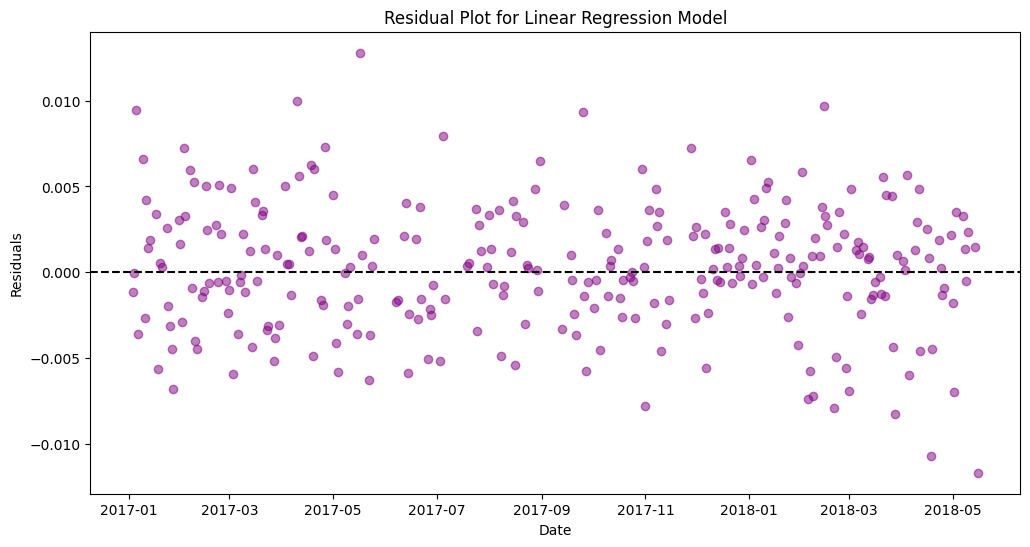

In [322]:
#visualization of the residuals of the linear regression model using the difference between the actual and predicted values
residuals = y_test_returns - lr_pred
plt.figure(figsize=(12, 6))
plt.scatter(returns_dff['Date'].loc[test_returns_mask], residuals, color='purple', alpha=0.5)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.title('Residual Plot for Linear Regression Model')
plt.show()

## Interpretation


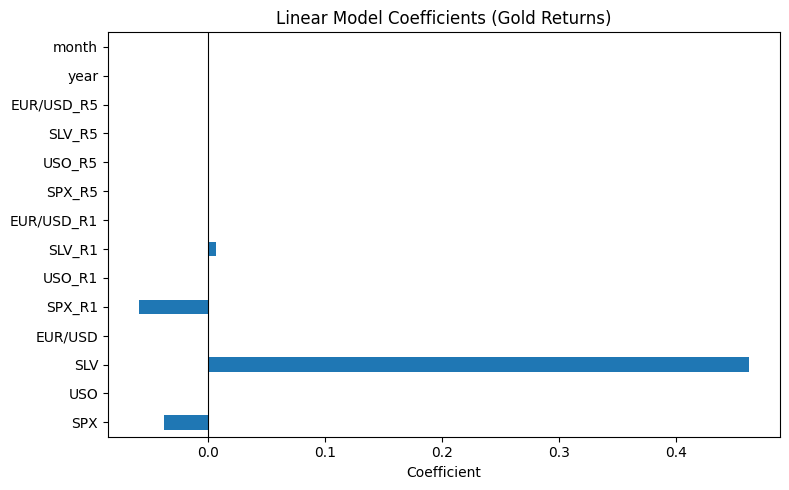

In [323]:
#remember lasso_coefs = pd.Series(best.coef_, index=X_train_real_returns.columns)


plt.figure(figsize=(8, 5))
lasso_coefs.plot(kind="barh")
plt.title("Linear Model Coefficients (Gold Returns)")
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

### What drives gold's returns

Silver dominates. Its coefficient (~0.46) is roughly 8× the next-largest
feature. Equities (SPX) show a small inverse effect,consistent with gold's
safe-haven behavior but it is minor. Oil (USO), the euro (EUR/USD), the
5-day rolling features, and the calendar variables contribute effectively
nothing. Gold's daily returns are, to a first approximation, explained by
silver's daily returns alone.



**Why levels failed but returns worked**
The price-level model collapsed out-of-sample (R² = −9.74) due to regime drift:
silver reached ~47 in training but sat at 15–17 in the 2017–2018 test period,
so the model extrapolated from a relationship that no longer held. Returns
strip out absolute price levels, so the "when silver moves, gold moves"
relationship stayed stable across regimes. This confirms non-stationarity as
the core modeling challenge.

**Where the model fails**
Residuals are clean random noise, evenly scattered around zero with constant
spread. The model under-predicts only on the most extreme days. It captures
the systematic silver-driven signal; the remaining ~31% of variance is
unpredictable noise, not missed structure.

## Results Summary

### Setup
This project **nowcasts** gold (GLD) daily values from four assets — silver
(SLV), the S&P 500 (SPX), oil (USO), and EUR/USD — measured the same day.
Two tracks were modeled and compared:
- **Price level** — predict GLD in dollars.
- **Daily returns** — predict GLD's daily return.
Data was split **chronologically** (train ≤ 2016, test 2017–May 2018) with
no shuffling, to prevent look-ahead leakage. Validation used TimeSeriesSplit.

### Headline finding
Gold's daily returns are driven **overwhelmingly by silver**. Silver alone
explains ~69% of gold's return variance out-of-sample; adding all other
features improves this by less than 1%.

### Model comparison (returns track, test R²)

| Model | Test R² | Notes |
|---|---|---|
| Gradient Boosting (tuned) | 0.696 | Matched linear(no gain from complexity) |
| Full Linear Regression | 0.696 | Simple and best-in-class |
| Lasso (6 features) | 0.695 | Same fit, half the features |
| **SLV-only baseline** | **0.687** | One feature(nearly matches everything) |
| Random Forest | 0.662 | Underperformed(no non-linear structure) |
| Ridge | 0.612 | Stable but shrunk |

### Level vs. returns
| Track | SLV-only Test R² | Outcome |
|---|---|---|
| **Returns** | **+0.687** | Stable, robust out-of-sample |
| **Level** | **−9.74** | Collapsed — regime drift / non-stationarity |

The price-level model failed out-of-sample because the silver–gold price
relationship drifted between the training and test eras. Returns removed this
drift, producing a stable relationship. This contrast is the project's core
methodological result.

### Conclusion
The silver–gold return relationship is **linear, stable, and data-limited**.
Every model family converges on ~0.69, confirming the performance ceiling is
set by available signal, not model choice. Simpler models are the right tool.

## Limitations

- **Explanatory, not predictive.** This is a nowcast — it uses same-day asset
  prices to explain same-day gold. It does not forecast future prices and is
  not a trading signal. The high R² reflects contemporaneous co-movement, not
  predictive power.

- **One dominant feature.** Silver does almost all the work; the other assets
  add little. The model is effectively a silver–gold relationship, so it offers
  limited insight into gold's broader drivers.

- **Non-stationarity.** Asset relationships drift over time. The price-level
  model failed out-of-sample for this reason, and even the returns model could
  weaken in a future regime unlike the training period.

- **Small, dated dataset.** ~2,290 daily rows ending May 2018. Results may not
  generalize to later periods or different market conditions.

- **Limited feature set.** Only four cross-asset prices. Real gold drivers
  (interest rates, inflation, the dollar index, geopolitical risk) are absent.

## Next Steps

- Add macro features — real interest rates, inflation expectations, the DXY
  dollar index — which are economically stronger gold drivers than silver.
- Extend the data past 2018 and re-test to check the relationship still holds.
- Test true forecasting (predicting next-day gold from today's data) rather
  than nowcasting, if prediction is the goal.
- Reduce redundant features (e.g. the SPX/SPX_R1 duplicates) for cleaner models.